### Module import

In [1]:
import matplotlib
from equilibrator_api import ComponentContribution
from equilibrator_pathway import ThermodynamicModel
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib_inline
from equilibrator_pathway.ecm_model import EnzymeCostModel

#backend_inline.set_matplotlib_formats('svg',dpi=300)
sns.set_style("dark")

D:\work\python\anaconda\install\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\work\python\anaconda\install\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
comp_contrib = ComponentContribution()

In [3]:
pp = ThermodynamicModel.from_sbtab("hydroxytyrosol_CCHT-1 and CCHT-2.tsv", comp_contrib=comp_contrib)
pp.update_standard_dgs()
pp.dg_confidence = 0.0  # 0.95

In [4]:
%%time
mdf_sol = pp.mdf_analysis()

Wall time: 115 ms


### Calculate the shadow prices of metabolites

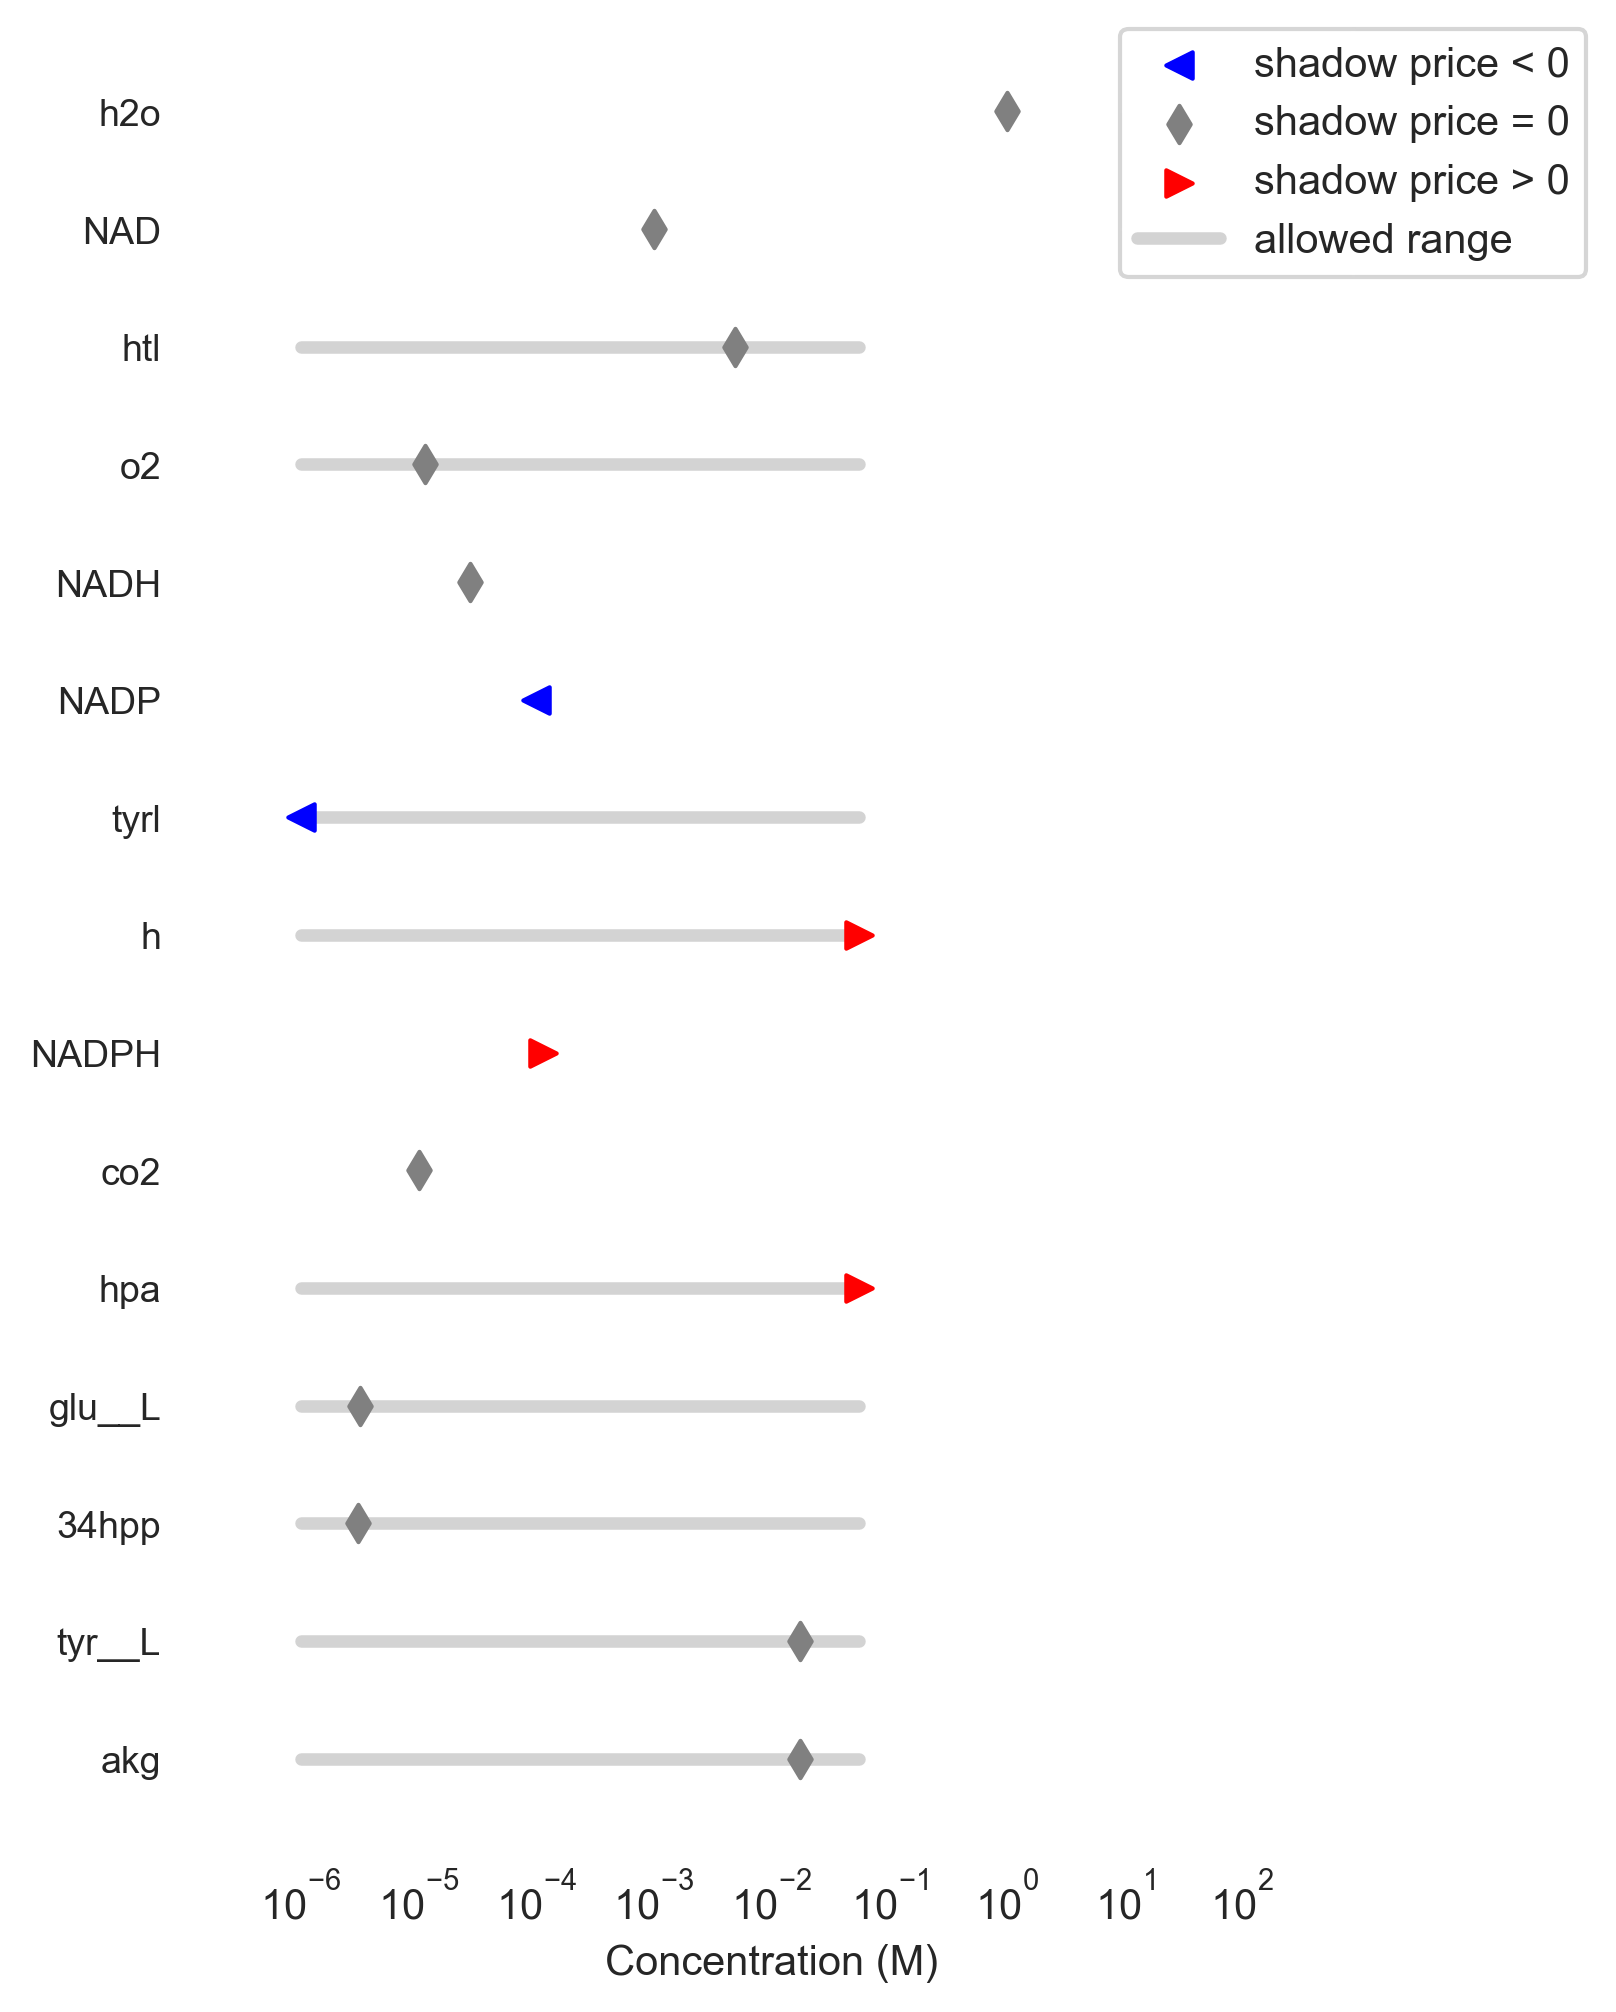

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(5, 8), dpi=300)
mdf_sol.plot_concentrations(ax=ax)
ax.axis('equal')
plt.xlim(10**-6,10**2)
#ax.legend(loc='upper right',fontsize='small',facecolor='none')
ax.legend(fontsize='small',facecolor='none')
plt.legend(bbox_to_anchor=(0.8, 1), loc=2, borderaxespad=0, facecolor='white')
#ax.spines['bottom'].set_linewidth(2)
#ax.spines['left'].set_linewidth(2)
#ax.spines['bottom'].set_color('black')
#ax.spines['left'].set_color('black')
ax.axes.yaxis.grid(True, which="major")
ax.set_facecolor('none')
plt.savefig("shadow price_hydroxytyrosol.svg", bbox_inches = 'tight',dpi=300,format="svg")

### Calculate the MDF value of the biosynthesis pathway for the two strains

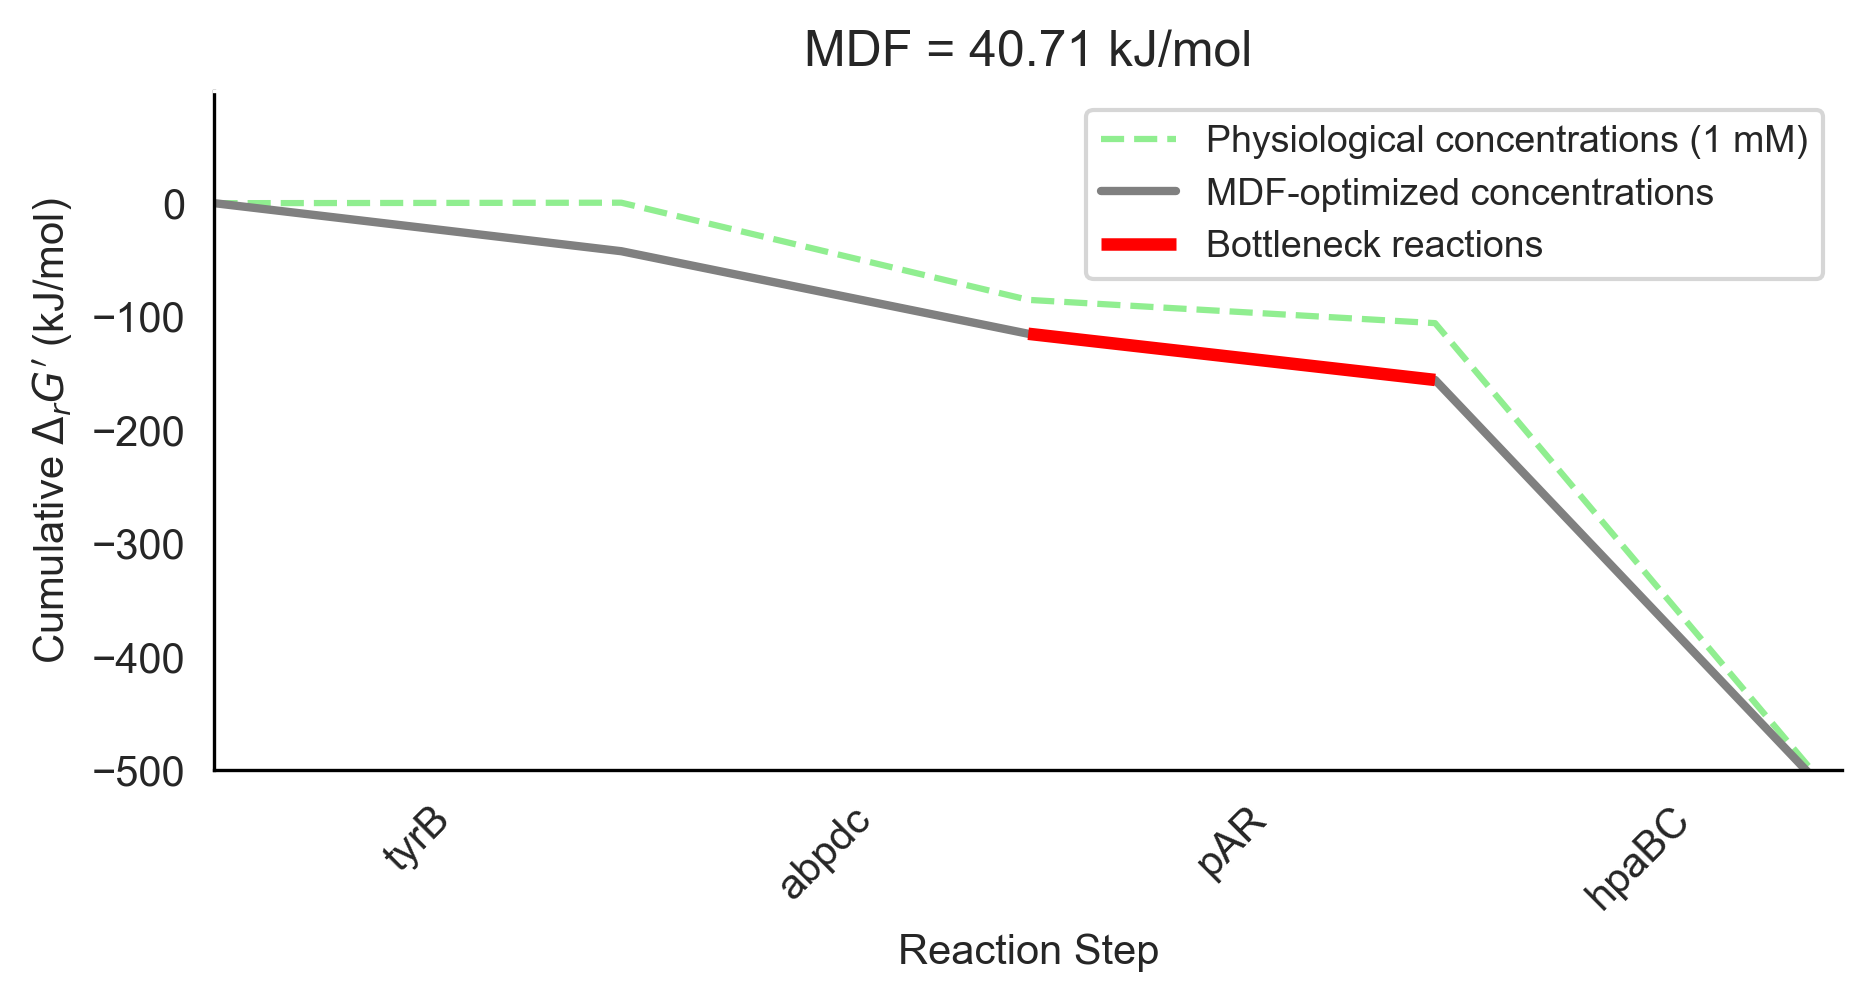

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3), dpi=300)
mdf_sol.plot_driving_forces(ax=ax)
plt.ylim(-500,99)
ax.legend(loc='upper right',fontsize=9,facecolor='none')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.axes.xaxis.grid(True, which="major")
ax.set_facecolor('none')
plt.savefig("MDF_hydroxytyrosol.svg", bbox_inches = 'tight',dpi=300,format="svg")

In [7]:
mdf_sol.reaction_df

,reaction_id,reaction_formula,flux,original_standard_dg_prime,standard_dg_prime,physiological_dg_prime,optimized_dg_prime,shadow_price
0,tyrB,akg + tyr__L = 34hpp + glu__L,0.0002 millimolar / second,0.4238716409940366 kilojoule / mole,0.4238716409940366 kilojoule / mole,0.4238716409940366 kilojoule / mole,-42.3473390145135 kilojoule / mole,0.0
1,abpdc,34hpp = co2 + hpa,0.0002 millimolar / second,-68.53155884100062 kilojoule / mole,-68.53155884100062 kilojoule / mole,-85.64639637572165 kilojoule / mole,-72.77481084921328 kilojoule / mole,0.0
2,pAR,NADPH + h + hpa = NADP + tyrl,0.0002 millimolar / second,-20.527475704639528 kilojoule / mole,-20.527475704639528 kilojoule / mole,-20.527475704639528 kilojoule / mole,-40.70710690263324 kilojoule / mole,1.0
3,hpaBC,NADH + h + o2 + tyrl = NAD + h2o + htl,0.0002 millimolar / second,-442.76082999018035 kilojoule / mole,-442.76082999018035 kilojoule / mole,-425.64599245545935 kilojoule / mole,-377.39360607222034 kilojoule / mole,0.0


# Data initialization